0.008688920198001895
raw unstrained: 4488360.56
raw 100g tail: -5261673.36
raw difference: -9750033.92


Text(0, 0.5, 'Sensor 0 (raw)')

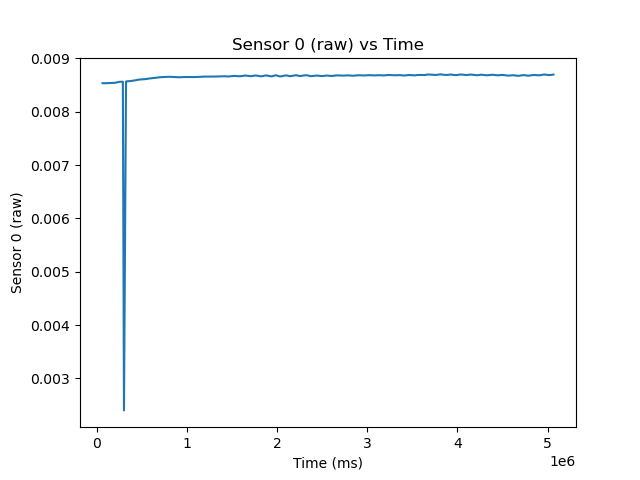

In [2]:
# As always, we start by importing our libraries
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import sounddevice as sd

from scipy.signal import welch # We'll need this for power spectral density estimation 

# Allow for interactive plotting in Jupyter notebooks, comment out to turn this off. 
# The % sign is a Jupyter magic command that enables the use of widgets in the notebook.
# This requires installing the ipympl package.
%matplotlib widget 

# For interactive data point selection in plots, this library is useful.
import mplcursors


VCC = 5.01  # set to 3.3 if your board is 3.3V

# get unstrained data
unstrained_data = pd.read_csv("/Users/caroline/Desktop/geng360-mahoney/Lab 4 - Beam/no_strain.csv") 
unstrained = unstrained_data["strain (raw)"].mean() # Calculate the mean of the unstrained data to use as a baseline

# convert unstrained to voltage
unstr_vout = (unstrained/128) * (VCC / 16777215) # Convert raw ADC values to voltage

myData = (pd.read_csv("/Users/caroline/Desktop/geng360-mahoney/Lab 4 - Beam/100g_part2.csv")) # Make sure to update this file name to match your data! 
myData["strain (raw)"] = -myData["strain (raw)"] # Invert the strain values to match the expected direction of positive strain
myData.head() #This will display the first few rows of the DataFrame


vout = (myData["strain (raw)"]/128) * (VCC / 16777215) # Convert raw ADC values to voltage
vr= (vout / VCC) - (unstr_vout / VCC) # Normalize voltage by supply voltage
strain = (-4 * vr)/(2.11*(1+(2*vr)))

print(strain.tail(100).mean())  # mean of last 100 samples

print("raw unstrained:", unstrained)
print("raw 100g tail:", myData["strain (raw)"].tail(50).mean())
print("raw difference:", myData["strain (raw)"].tail(50).mean() - unstrained)

"""loads = [10, 20, 30, 50, 100]  # grams
files = ["no_strain.csv", "10g.csv", "20g.csv", "30g.csv", "50g.csv", "100g.csv"]

results = []
for load, file in zip(loads, files):
    data = pd.read_csv(f"/Users/caroline/Desktop/geng360-mahoney/Lab 4 - Beam/{file}")
    vout = (data["strain (raw)"] / 128) * (VCC / 16777215)
    vr = (vout - unstr_vout) / VCC
    strain = (4 * vr) / (2.11 * (1 + (2 * vr)))
    results.append({"load_g": load, "strain": strain.mean()})

    # Plot each load
    plt.figure()
    sns.lineplot(x="Times (us)", y=strain, data=data)
    plt.title(f"Strain vs Time — {load}g load")
    plt.xlabel("Time (us)")
    plt.ylabel("Strain (ε)")
    mplcursors.cursor(hover=False)
    plt.show()

results_df = pd.DataFrame(results)
print(results_df)"""

plt.figure()  # Create a new figure
sns.lineplot(x="Times (us)", y= strain, data=myData)
plt.title("Sensor 0 (raw) vs Time")
plt.xlabel("Time (ms)")
plt.ylabel("Sensor 0 (raw)")

#mplcursors.cursor(hover=False)  # Enable interactive cursor for data point selection

# Click anywhere on your data to add a cursor
# Right-click to remove a cursor

#plt.show()